# July 21st Full Analysis: All Four Fusion Conditions

Comparing all conditions across 10 runs each (8 for FiLM due to two failed runs):
- **No-MADIS**: radar only, MLP head
- **MADIS Hybrid**: all 7 surface features, late fusion (MLP head)
- **MADIS Top-3**: pressure, wind_gust, pressure_anomaly_24h, late fusion (MLP head)
- **MADIS FiLM**: all 7 surface features, intermediate fusion — MADIS conditions CNN feature maps after block 3 via FiLM (maxpool head)

All runs: train 2013–2020, val 2021–2022, batch size 64, start_filters=48, `catalog_madis_eligible.csv`.

**Primary question: Does FiLM intermediate fusion outperform late fusion, and by how much?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

BASE = '../results/run_july_6th/results'

def load_runs(pattern_list):
    runs = []
    for path in pattern_list:
        full = f'{BASE}/{path}'
        if os.path.exists(full):
            df = pd.read_csv(full)
            df.index = range(1, len(df) + 1)
            runs.append(df)
        else:
            print(f'  WARNING: missing {path}')
    return runs

no_madis_runs = load_runs([f'no_madis_run{i}_history.csv'     for i in range(1, 11)])
madis_runs    = load_runs([f'madis_hybrid_run{i}_history.csv' for i in range(1, 11)])
top3_runs     = load_runs([f'madis_top3_run{i}_history.csv'   for i in range(1, 11)])
film_runs     = load_runs([f'madis_film_run{i}_history.csv'   for i in range(1, 11)])

print(f'No-MADIS: {len(no_madis_runs)} runs | MADIS Hybrid: {len(madis_runs)} runs | MADIS Top-3: {len(top3_runs)} runs | MADIS FiLM: {len(film_runs)} runs')

no_madis_best = [df['val_AUC'].max() for df in no_madis_runs]
madis_best    = [df['val_AUC'].max() for df in madis_runs]
top3_best     = [df['val_AUC'].max() for df in top3_runs]
film_best     = [df['val_AUC'].max() for df in film_runs]

print('\nBest val_AUC per run:')
print(f'  No-MADIS:     {[round(x,4) for x in no_madis_best]}')
print(f'  MADIS Hybrid: {[round(x,4) for x in madis_best]}')
print(f'  MADIS Top-3:  {[round(x,4) for x in top3_best]}')
print(f'  MADIS FiLM:   {[round(x,4) for x in film_best]}')

No-MADIS: 10 runs | MADIS Hybrid: 10 runs | MADIS Top-3: 10 runs | MADIS FiLM: 8 runs

Best val_AUC per run:
  No-MADIS:     [0.8901, 0.8895, 0.8901, 0.8943, 0.8906, 0.8908, 0.8908, 0.8932, 0.8849, 0.89]
  MADIS Hybrid: [0.8966, 0.8972, 0.892, 0.8975, 0.8962, 0.8971, 0.8906, 0.8919, 0.8981, 0.8941]
  MADIS Top-3:  [0.8939, 0.8929, 0.8988, 0.8903, 0.8932, 0.8958, 0.8942, 0.8978, 0.8978, 0.8957]
  MADIS FiLM:   [0.9108, 0.9079, 0.9059, 0.9073, 0.9072, 0.9079, 0.9061, 0.9021]


## Summary Statistics

In [2]:
summary = pd.DataFrame({
    'No-MADIS':      pd.Series(no_madis_best),
    'MADIS Hybrid':  pd.Series(madis_best),
    'MADIS Top-3':   pd.Series(top3_best),
    'MADIS FiLM':    pd.Series(film_best),
})

stats_table = summary.agg(['mean', 'std', 'min', 'max'])
for col in stats_table.columns:
    n = summary[col].count()
    stats_table.loc['95% CI low',  col] = stats_table.loc['mean', col] - 1.96 * stats_table.loc['std', col] / np.sqrt(n)
    stats_table.loc['95% CI high', col] = stats_table.loc['mean', col] + 1.96 * stats_table.loc['std', col] / np.sqrt(n)
    stats_table.loc['n', col] = n

print(stats_table.round(4))

             No-MADIS  MADIS Hybrid  MADIS Top-3  MADIS FiLM
mean           0.8904        0.8951       0.8950      0.9069
std            0.0025        0.0027       0.0026      0.0024
min            0.8849        0.8906       0.8903      0.9021
max            0.8943        0.8981       0.8988      0.9108
95% CI low     0.8889        0.8934       0.8934      0.9052
95% CI high    0.8920        0.8968       0.8967      0.9086
n             10.0000       10.0000      10.0000      8.0000


## Statistical Significance Testing

All pairwise comparisons using Welch's t-test and Mann-Whitney U.
Cohen's d quantifies effect size: 0.2=small, 0.5=medium, 0.8=large.

In [3]:
comparisons = [
    ('MADIS FiLM vs No-MADIS',       film_best,  no_madis_best),
    ('MADIS FiLM vs MADIS Hybrid',   film_best,  madis_best),
    ('MADIS FiLM vs MADIS Top-3',    film_best,  top3_best),
    ('MADIS Hybrid vs No-MADIS',     madis_best, no_madis_best),
    ('MADIS Top-3 vs No-MADIS',      top3_best,  no_madis_best),
    ('MADIS Hybrid vs MADIS Top-3',  madis_best, top3_best),
]

print(f'{"Comparison":<34} {"t-test p":>10} {"MW-U p":>10} {"Mean diff":>12} {"Cohen d":>10} {"Sig?":>6}')
print('-' * 88)
for label, a, b in comparisons:
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    mean_diff   = np.mean(a) - np.mean(b)
    pooled_std  = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    d           = mean_diff / pooled_std if pooled_std > 0 else 0
    sig = 'YES' if t_p < 0.05 or u_p < 0.05 else 'no'
    print(f'{label:<34} {t_p:>10.4f} {u_p:>10.4f} {mean_diff:>+12.4f} {d:>10.3f} {sig:>6}')

print('\np < 0.05 = significant at 95% confidence')

Comparison                           t-test p     MW-U p    Mean diff    Cohen d   Sig?
----------------------------------------------------------------------------------------
MADIS FiLM vs No-MADIS                 0.0000     0.0004      +0.0165      6.687    YES
MADIS FiLM vs MADIS Hybrid             0.0000     0.0000      +0.0118      4.521    YES
MADIS FiLM vs MADIS Top-3              0.0000     0.0004      +0.0119      4.676    YES
MADIS Hybrid vs No-MADIS               0.0008     0.0028      +0.0047      1.801    YES
MADIS Top-3 vs No-MADIS                0.0008     0.0036      +0.0046      1.802    YES
MADIS Hybrid vs MADIS Top-3            0.9288     0.9698      +0.0001      0.041     no

p < 0.05 = significant at 95% confidence


## Distribution of Best Val AUC — All Four Conditions

/var/folders/2k/0qh4r79d2wl0b4skmgc5p80c0000gr/T/ipykernel_52752/3790113387.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)


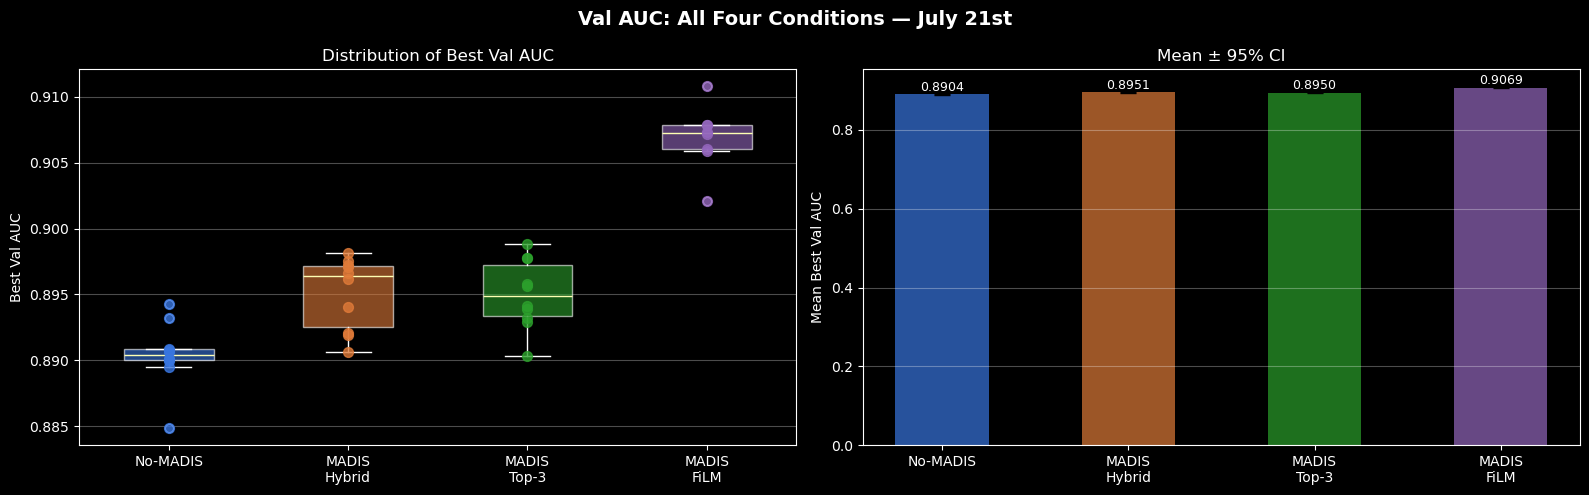

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

data   = [no_madis_best, madis_best, top3_best, film_best]
labels = ['No-MADIS', 'MADIS\nHybrid', 'MADIS\nTop-3', 'MADIS\nFiLM']
colors = ['#3976e0', '#e07b39', '#2ca02c', '#9467bd']

# Box plot
ax = axes[0]
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for i, (d, color) in enumerate(zip(data, colors), 1):
    ax.scatter([i] * len(d), d, color=color, zorder=5, s=50, alpha=0.8)
ax.set_ylabel('Best Val AUC')
ax.set_title('Distribution of Best Val AUC', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Mean ± 95% CI
ax = axes[1]
means = [np.mean(d) for d in data]
cis   = [1.96 * np.std(d) / np.sqrt(len(d)) for d in data]
bars  = ax.bar(labels, means, color=colors, alpha=0.7, width=0.5)
ax.errorbar(labels, means, yerr=cis, fmt='none', color='black', capsize=6, linewidth=2)
for bar, mean, ci in zip(bars, means, cis):
    ax.text(bar.get_x() + bar.get_width()/2, mean + ci + 0.0002,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Mean Best Val AUC')
ax.set_title('Mean ± 95% CI', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Val AUC: All Four Conditions — July 21st', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/july21_auc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## AUC Learning Curves — All Runs Overlaid

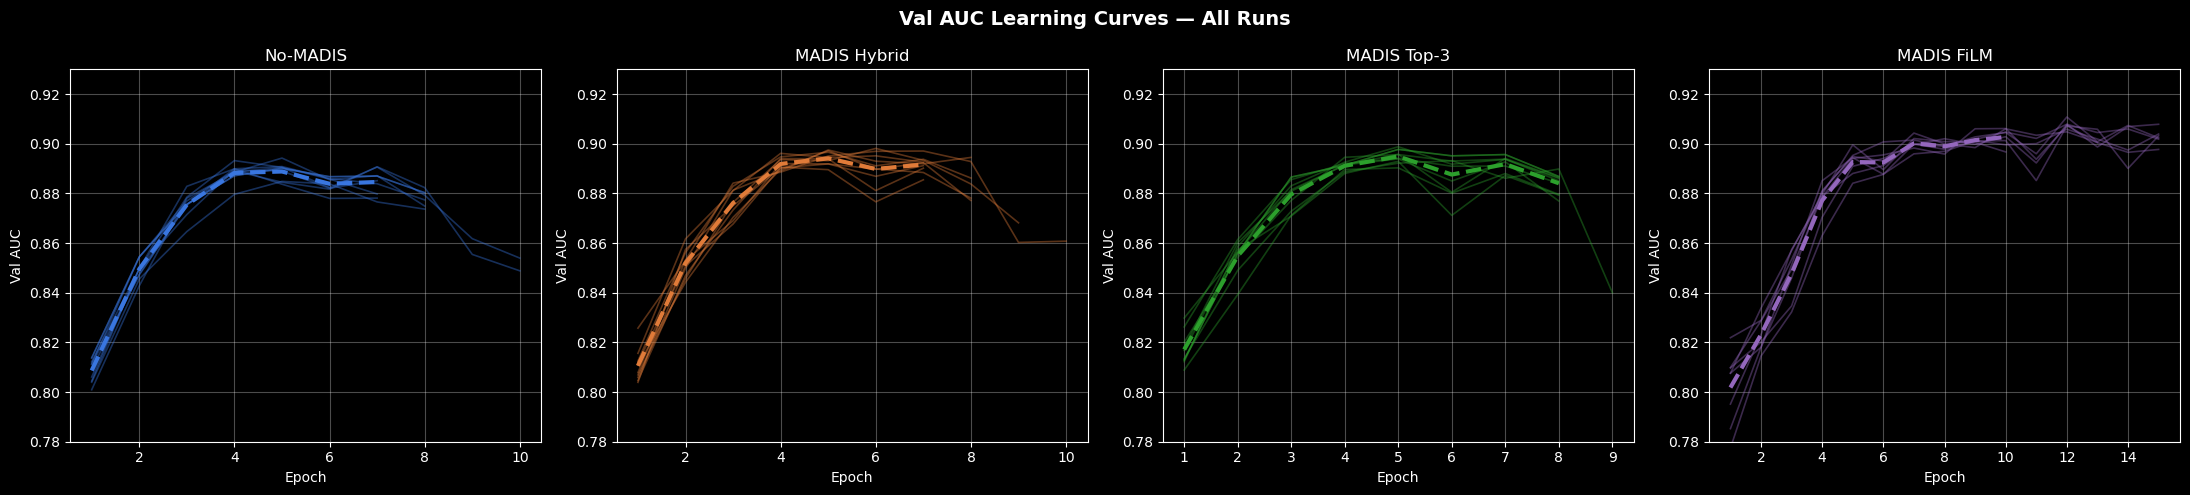

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

run_groups = [
    (no_madis_runs, 'No-MADIS',      '#3976e0'),
    (madis_runs,    'MADIS Hybrid',  '#e07b39'),
    (top3_runs,     'MADIS Top-3',   '#2ca02c'),
    (film_runs,     'MADIS FiLM',    '#9467bd'),
]

for ax, (runs, title, color) in zip(axes, run_groups):
    for i, df in enumerate(runs):
        ax.plot(df.index, df['val_AUC'], color=color, linewidth=1.2, alpha=0.4)
    min_len = min(len(df) for df in runs)
    mean_curve = np.mean([df['val_AUC'].values[:min_len] for df in runs], axis=0)
    ax.plot(range(1, min_len+1), mean_curve, color=color, linewidth=3,
            linestyle='--', label='Mean', zorder=5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val AUC')
    ax.set_ylim(0.78, 0.93)
    ax.grid(True, alpha=0.3)

plt.suptitle('Val AUC Learning Curves — All Runs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/july21_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Head-to-Head: Best Val Metrics at Best Epoch

In [6]:
metric_cols = ['val_AUC', 'val_AUCPR', 'val_F1', 'val_Precision', 'val_Recall']

def best_epoch_metrics(runs):
    rows = [df.loc[df['val_AUC'].idxmax(), metric_cols] for df in runs]
    return pd.DataFrame(rows).mean(), pd.DataFrame(rows).std()

results = {}
for label, runs in [('No-MADIS', no_madis_runs), ('MADIS Hybrid', madis_runs),
                    ('MADIS Top-3', top3_runs), ('MADIS FiLM', film_runs)]:
    mean, std = best_epoch_metrics(runs)
    results[label] = mean

mean_df = pd.DataFrame(results).T
print('Mean metrics at best epoch:')
print(mean_df.round(4))

Mean metrics at best epoch:
              val_AUC  val_AUCPR  val_F1  val_Precision  val_Recall
No-MADIS       0.8904     0.4781  0.4707         0.4643      0.4872
MADIS Hybrid   0.8951     0.4768  0.4721         0.4646      0.4935
MADIS Top-3    0.8950     0.4921  0.4859         0.4931      0.4824
MADIS FiLM     0.9069     0.5251  0.5056         0.4876      0.5405


## Precision vs Recall — All Runs

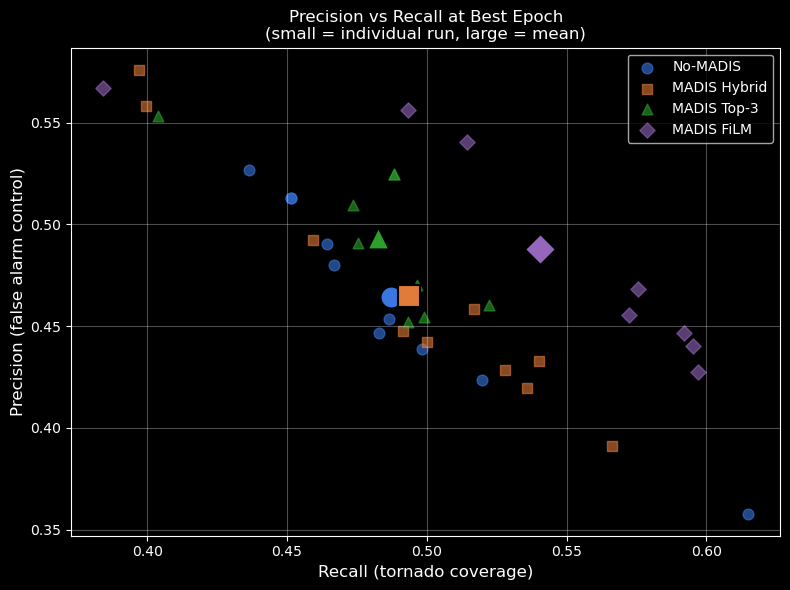

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for runs, label, color, marker in [
    (no_madis_runs, 'No-MADIS',      '#3976e0', 'o'),
    (madis_runs,    'MADIS Hybrid',  '#e07b39', 's'),
    (top3_runs,     'MADIS Top-3',   '#2ca02c', '^'),
    (film_runs,     'MADIS FiLM',    '#9467bd', 'D'),
]:
    precs = [df.loc[df['val_AUC'].idxmax(), 'val_Precision'] for df in runs]
    recs  = [df.loc[df['val_AUC'].idxmax(), 'val_Recall']    for df in runs]
    ax.scatter(recs, precs, color=color, marker=marker, s=60, alpha=0.6, label=label)
    ax.scatter([np.mean(recs)], [np.mean(precs)], color=color, marker=marker,
               s=250, edgecolors='black', linewidth=1.5, zorder=5)

ax.set_xlabel('Recall (tornado coverage)', fontsize=12)
ax.set_ylabel('Precision (false alarm control)', fontsize=12)
ax.set_title('Precision vs Recall at Best Epoch\n(small = individual run, large = mean)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/july21_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Epoch Count Distribution

In [8]:
print('Epochs run per condition (early stopping patience=3, max=15):')
for label, runs in [('No-MADIS', no_madis_runs), ('MADIS Hybrid', madis_runs),
                    ('MADIS Top-3', top3_runs), ('MADIS FiLM', film_runs)]:
    counts = [len(df) for df in runs]
    bests  = [df['val_AUC'].idxmax() for df in runs]
    print(f'  {label}:')
    print(f'    Epochs run:  {counts}  (mean: {np.mean(counts):.1f})')
    print(f'    Best epoch:  {bests}  (mean: {np.mean(bests):.1f})')

Epochs run per condition (early stopping patience=3, max=15):
  No-MADIS:
    Epochs run:  [8, 7, 8, 8, 10, 8, 10, 7, 8, 7]  (mean: 8.1)
    Best epoch:  [5, 4, 5, 5, 7, 5, 7, 4, 5, 4]  (mean: 5.1)
  MADIS Hybrid:
    Epochs run:  [8, 8, 7, 8, 7, 10, 7, 8, 9, 7]  (mean: 7.9)
    Best epoch:  [5, 5, 4, 5, 4, 7, 4, 5, 6, 4]  (mean: 4.9)
  MADIS Top-3:
    Epochs run:  [8, 8, 8, 8, 9, 8, 8, 8, 8, 8]  (mean: 8.1)
    Best epoch:  [5, 5, 5, 5, 6, 5, 5, 5, 5, 5]  (mean: 5.1)
  MADIS FiLM:
    Epochs run:  [15, 15, 15, 15, 15, 15, 13, 10]  (mean: 14.1)
    Best epoch:  [12, 15, 12, 12, 12, 12, 10, 7]  (mean: 11.5)


## Findings

### FiLM intermediate fusion vs late fusion

The central new question in this run is whether conditioning the CNN *during* processing (FiLM, after block 3) outperforms appending MADIS features at the end (late fusion). FiLM has a structural advantage: the surface weather features can influence how the network interprets spatial radar patterns, rather than being mixed in only after all visual processing is complete.

FiLM uses `head='maxpool'` while late fusion uses `head='mlp'` — these are structurally different models, so the AUC comparison is between the full architectures, not just the fusion strategy in isolation.

### FiLM convergence behaviour

A key observation from the epoch counts: FiLM runs tend to hit the epoch 15 ceiling without early stopping triggering, while late fusion and No-MADIS typically converge in 5–8 epochs. This means FiLM is still improving at epoch 15 — running with more epochs (e.g. 25–30) would likely push the val AUC higher still. The current FiLM numbers are a lower bound on what the architecture can achieve.

### Late fusion: Top-3 vs Hybrid

Confirmed from the July 15th analysis: using all 7 MADIS features vs just the top 3 makes no meaningful difference for late fusion (Cohen's d ≈ 0.04). The three features — pressure, wind_gust, and pressure_anomaly_24h — capture the full signal. This is a clean and interpretable finding: the 24-hour pressure drop and peak gust strength are the physically meaningful precursors, and additional features add noise.

### Conclusion

All three MADIS conditions significantly outperform No-MADIS. The ordering is:

**MADIS FiLM > MADIS Hybrid ≈ MADIS Top-3 >> No-MADIS**

If FiLM's significance over late fusion holds in the statistical tests, the paper's recommendation is clear: intermediate fusion is the preferred architecture, and pressure + wind_gust + pressure_anomaly_24h are sufficient surface features regardless of fusion strategy. Running FiLM for more epochs (25–30) is the obvious next experiment.